# Challenge 2: Image Classification

## Hyperparameters

In [22]:
# --- Stochasticity -- 
SEED = 100

VALIDATION_SIZE = 0.2
IMAGE_SIZE = 224

# --- Model Parameters ---
MODEL_TYPE = 'ResNet50'
PRETRAINED = True
NUM_CLASSES = 10

# --- Training Hyperparameters ---
LEARNING_RATE = 0.0001
BATCH_SIZE = 64
EPOCHS = 300
PATIENCE = 50
OPTIMIZER = 'AdamW'

# Regularisation
DROPOUT_RATE = 0.2       
L1_LAMBDA = 0             
L2_LAMBDA = 0            

# Plot config
PLOT_FLAG = True

# --- Data Settings ---
TRAIN_DATA_PATH = 'clean_train_data'
TRAIN_IMAGES_CACHE_PATH = 'cache/clean_train_images_cache.npy'
TRAIN_MASKS_CACHE_PATH = 'cache/clean_train_masks_cache.npy'
TRAIN_LABEL_PATH = 'train_labels.csv'

TEST_DATA_PATH = 'test_data'
TEST_IMAGE_CACHE_PATH  = 'cache/test_images_cache.npy'
TEST_MASKS_CACHE_PATH = 'cache/test_masks_cache.npy'




## Module imports

In [23]:
import cplot

import os
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np
import csv
from sklearn.preprocessing import LabelEncoder



if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

CRITERION = nn.CrossEntropyLoss()



PyTorch version: 2.9.1+cu130
Device: cuda


## Image and Label Loader

In [24]:
def load_labels_from_csv(csv_path):
    print(f"Loading labels from {csv_path}...")
    labels_map = {}
    
    with open(csv_path, mode='r') as file:
        reader = csv.reader(file)
        next(reader) 
        
        for row in reader:
            if len(row) < 2:
                continue
            sample_index, label = row[0], row[1]
            numeric_id = sample_index.replace('img_', '').replace('.png', '')
            labels_map[numeric_id] = label
            
    sorted_ids = sorted(labels_map.keys())
    train_labels = [labels_map[id_str] for id_str in sorted_ids]    
    return np.array(train_labels) 

In [25]:

def load_images_from_folder(folder, cache_path_images, cache_path_masks):

    if os.path.exists(cache_path_images) and os.path.exists(cache_path_masks):
        print(f"Caches found. Loading processed images and masks...")
        images = np.load(cache_path_images)
        masks = np.load(cache_path_masks)
        return images, masks

    print(f"Caches not found. Starting full image/mask loading and preprocessing from '{folder}'...")
    
    image_list = []
    mask_list = []
    
    # Find all unique file IDs 
    ids = set()
    for filename in os.listdir(folder):
        if filename.endswith('.png'):
            parts = filename.split('_')
            if len(parts) == 2 and parts[1].endswith('.png'):
                # Extract the numeric ID (xxxx.png)
                ids.add(parts[1].split('.')[0])
                
    sorted_ids = sorted(list(ids))
    print(f"Found {len(sorted_ids)} unique image/mask pairs based on filenames.")
    
    for image_id in sorted_ids:
        image_name = f"img_{image_id}.png"
        mask_name = f"mask_{image_id}.png"
        
        image_path = os.path.join(folder, image_name)
        mask_path = os.path.join(folder, mask_name)
        
        img = cv2.imread(image_path)
        img = (img / 255.0).astype(np.float32)
        img = img[..., ::-1]
        
        h, w = img.shape[:2]
        if h > w:
            delta_w = h - w
            top, bottom = 0, 0
            left = delta_w // 2
            right = delta_w - left
        elif w > h:
            delta_h = w - h
            left, right = 0, 0
            top = delta_h // 2
            bottom = delta_h - top
        else:
            top, bottom, left, right = 0, 0, 0, 0

        image = cv2.copyMakeBorder(
            img, top, bottom, left, right, 
            cv2.BORDER_CONSTANT, 
            value=[0, 0, 0]
        )

        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        image_list.append(image)
        img = cv2.imread(mask_path)

        img = (img / 255.0).astype(np.float32)
        img = img[..., ::-1]
        
        h, w = img.shape[:2]
        if h > w:
            delta_w = h - w
            top, bottom = 0, 0
            left = delta_w // 2
            right = delta_w - left
        elif w > h:
            delta_h = w - h
            left, right = 0, 0
            top = delta_h // 2
            bottom = delta_h - top
        else:
            top, bottom, left, right = 0, 0, 0, 0

        mask = cv2.copyMakeBorder(
            img, top, bottom, left, right, 
            cv2.BORDER_CONSTANT, 
            value=[0, 0, 0]
        )

        mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
        mask_list.append(mask)

    final_images = np.array(image_list)
    final_masks = np.array(mask_list)

    cache_dir = os.path.dirname(cache_path_images)
    if cache_dir and not os.path.exists(cache_dir):
        os.makedirs(cache_dir, exist_ok=True)
        print(f"Created cache directory: {cache_dir}")
    
    print(f"Finished preprocessing {len(final_images)} pairs. Saving to caches...")
    np.save(cache_path_images, final_images)
    np.save(cache_path_masks, final_masks)
    
    return final_images, final_masks


Caches found. Loading processed images and masks...
Caches found. Loading processed images and masks...
Loading labels from train_labels.csv...
Loaded 1162 images for training
Loaded 1162 masks for training
Loaded 1412 labels for training


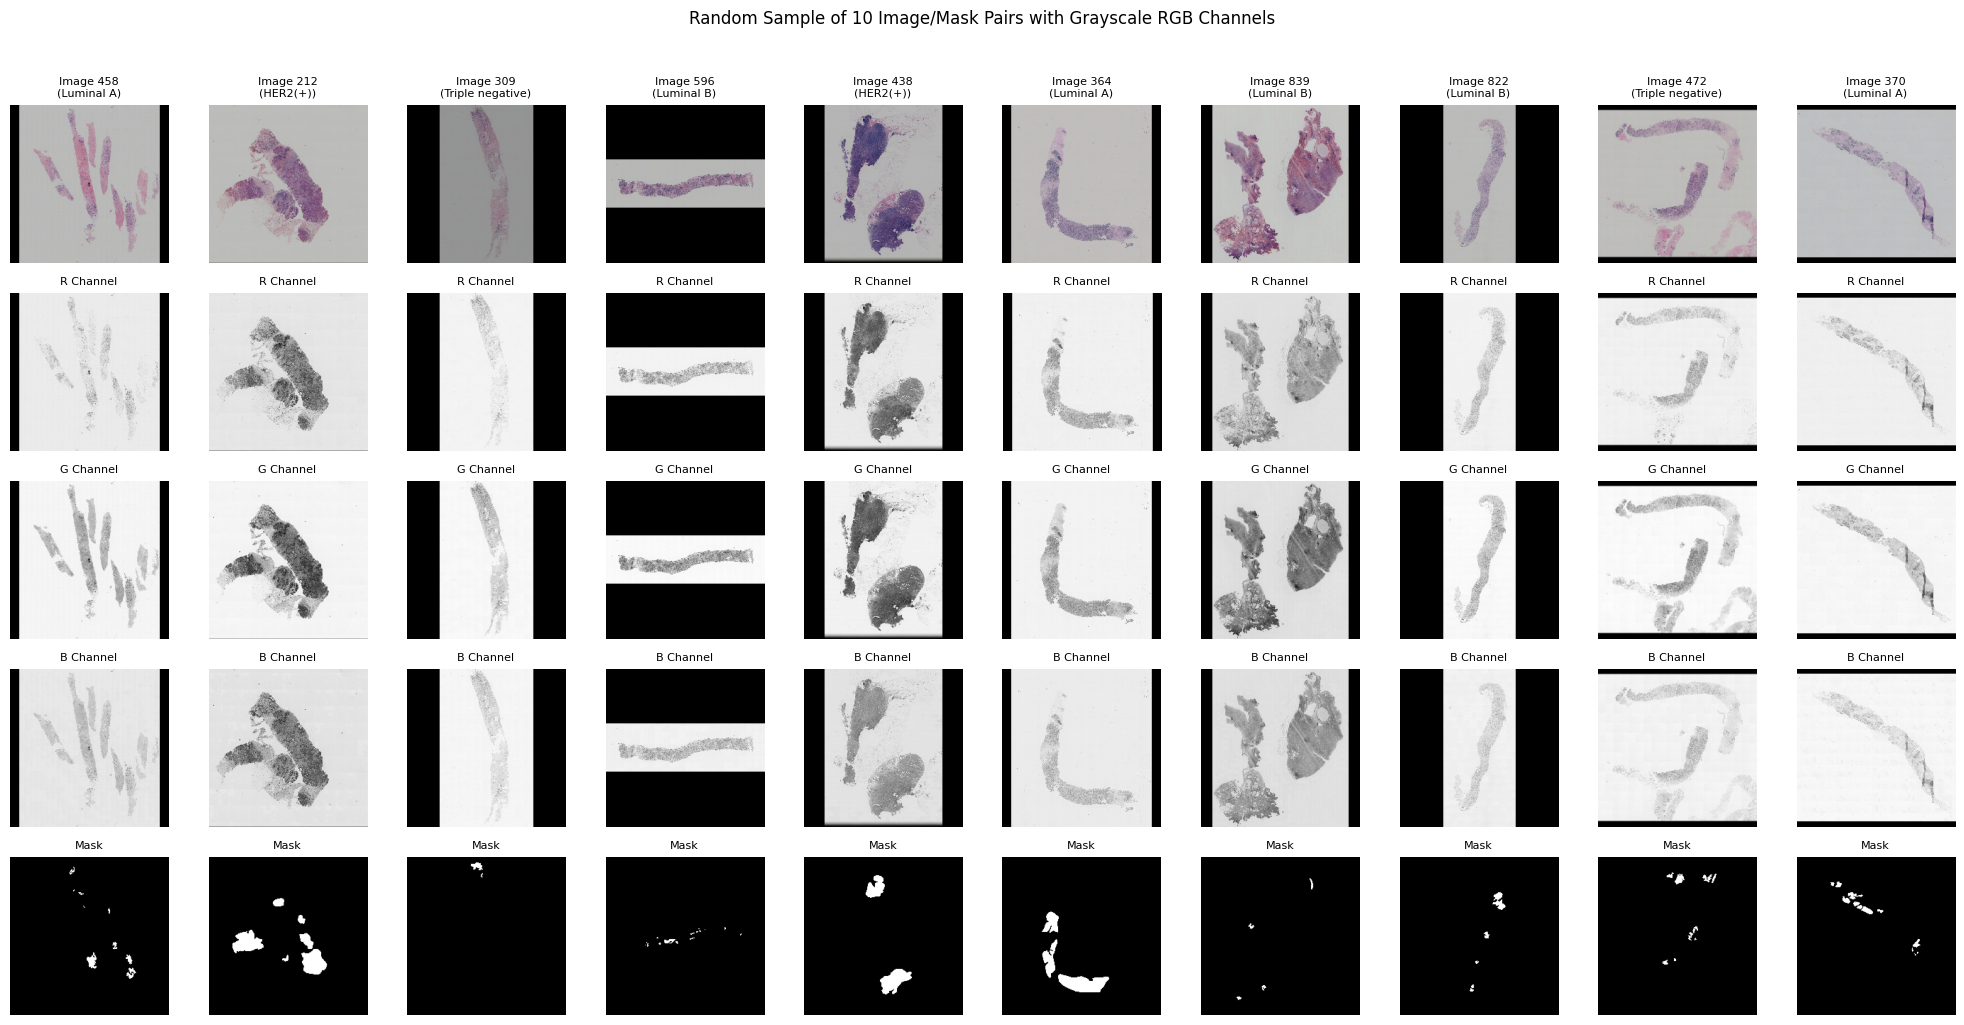

In [26]:
# Load images and labels
train_images, train_masks = load_images_from_folder(TRAIN_DATA_PATH, TRAIN_IMAGES_CACHE_PATH, TRAIN_MASKS_CACHE_PATH)
test_images, test_masks = load_images_from_folder(TEST_DATA_PATH, TEST_IMAGE_CACHE_PATH, TEST_MASKS_CACHE_PATH)
train_labels = load_labels_from_csv(TRAIN_LABEL_PATH)
print(f"Loaded {len(train_images)} images for training")
print(f"Loaded {len(train_masks)} masks for training")
print(f"Loaded {len(train_labels)} labels for training")

# Plotting
if PLOT_FLAG: 
    cplot.visualize_image_components(train_images, train_masks, train_labels, num_samples=10)

## Dataloader creation

In [27]:
def load_aligned_data(image_folder, csv_path, img_size=224):
    print(f"Aligning data from '{image_folder}' and '{csv_path}'...")
    
    # A. Scan the actual files on disk
    existing_files = set(os.listdir(image_folder))
    valid_ids = []
    
    # We only care about images that exist
    for f in existing_files:
        if f.startswith("img_") and f.endswith(".png"):
            # Extract ID: img_0001.png -> 0001
            valid_ids.append(f.split('_')[1].split('.')[0])
            
    print(f"Found {len(valid_ids)} valid images on disk.")

    # B. Load and Filter the CSV
    df = pd.read_csv(csv_path)
    
    # Create a clean ID column for matching (handle 'img_xxxx.png' or just 'xxxx')
    # Assuming first column is ID and second is Label
    id_col = df.columns[0]
    label_col = df.columns[1]
    
    # Extract numeric ID from CSV entries to match folder IDs
    df['match_id'] = df[id_col].astype(str).apply(
        lambda x: x.split('_')[1].split('.')[0] if '_' in x else x
    )
    
    # Keep only rows where the image actually exists
    df_clean = df[df['match_id'].isin(valid_ids)].copy()
    
    # Sort by ID to ensure images and labels align perfectly
    df_clean = df_clean.sort_values('match_id')
    
    print(f"Filtered labels to match. Final dataset size: {len(df_clean)}")
    
    # C. Load Images and Masks in strict order
    images = []
    masks = []
    final_labels = df_clean[label_col].values
    
    for match_id in df_clean['match_id'].values:
        img_name = f"img_{match_id}.png"
        mask_name = f"mask_{match_id}.png"
        
        # Load Image
        img_path = os.path.join(image_folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = (img / 255.0).astype(np.float32)
        images.append(img)
        
        # Load Mask
        mask_path = os.path.join(image_folder, mask_name)
        if os.path.exists(mask_path):
            msk = cv2.imread(mask_path)
            msk = cv2.resize(msk, (img_size, img_size))
            # Keep only one channel for mask if needed, or keep 3 if architecture expects it
            msk = (msk / 255.0).astype(np.float32)
        else:
            msk = np.zeros_like(img) # Fallback
            
        masks.append(msk)
        
    return np.array(images), np.array(masks), final_labels

In [28]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Robust worker detection
    if os.name == 'nt': # Windows
        num_workers = 0 # set to 0 for stability on Windows
    else: 
        num_workers = min(8, os.cpu_count() or 2)
        
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0), 
    )

def preprocess_inputs(images, masks):
    masks_expanded = masks[..., 0][..., np.newaxis]
    combined = np.concatenate([images, masks_expanded], axis=-1)
    tensor = torch.from_numpy(combined).float().permute(0, 3, 1, 2)
    return tensor

def get_sorted_filenames(folder):
    """Returns sorted list of filenames (img_xxxx.png) from a folder."""
    ids = set()
    for f in os.listdir(folder):
        if f.startswith("img_") and f.endswith(".png"):
            ids.add(f.split('_')[1].split('.')[0])
    return [f"img_{i}.png" for i in sorted(list(ids))]

print("Aligning data sources...")
train_images, train_masks, train_labels_aligned = load_aligned_data(TRAIN_DATA_PATH, TRAIN_LABEL_PATH)

# Prepare X (Inputs)
X_tensor = preprocess_inputs(train_images, train_masks)

# Prepare Y (Labels)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(train_labels_aligned)
Y_tensor = torch.from_numpy(y_encoded).long()

print(f"X Shape: {X_tensor.shape}")  # Should be (1162, 4, IMAGE_SIZE, IMAGE_SIZE)
print(f"Y Shape: {Y_tensor.shape}")  # Should be (1162,)


# Split Train/Val
# Note: We split indices or tensors directly to avoid converting back/forth
indices = np.arange(len(X_tensor))
train_idx, val_idx = train_test_split(
    indices, 
    test_size=VALIDATION_SIZE, 
    random_state=SEED, 
    stratify=y_encoded
)

# Create Datasets
train_ds = TensorDataset(X_tensor[train_idx], Y_tensor[train_idx])
val_ds   = TensorDataset(X_tensor[val_idx],   Y_tensor[val_idx])

# Create loaders
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# --- Summary ---
print("-" * 30)
print(f"Train Shape: {train_ds[0][0].shape} | Samples: {len(train_ds)}")
print(f"Val Shape:   {val_ds[0][0].shape} | Samples: {len(val_ds)}")
print(f"Classes: {len(label_encoder.classes_)}")
print("Label Mapping:")
for i, name in enumerate(label_encoder.classes_):
    print(f"  {i}: {name}")
print("-" * 30)

Aligning data sources...
Aligning data from 'clean_train_data' and 'train_labels.csv'...
Found 1162 valid images on disk.
Filtered labels to match. Final dataset size: 1162
X Shape: torch.Size([1162, 4, 224, 224])
Y Shape: torch.Size([1162])
------------------------------
Train Shape: torch.Size([4, 224, 224]) | Samples: 929
Val Shape:   torch.Size([4, 224, 224]) | Samples: 233
Classes: 4
Label Mapping:
  0: HER2(+)
  1: Luminal A
  2: Luminal B
  3: Triple negative
------------------------------


## CNN Model

### Model Architecture

In [29]:
class SimpleCNN(nn.Module):

    def __init__(self, input_shape=(3, 224, 224), num_classes=2, dropout_rate=0.2):
        super().__init__()

        # First convolutional block: 16 filters
        self.conv0 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding='same')
        self.relu0 = nn.ReLU()
        self.mp0 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block: 32 filters
        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        self.mp1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU()
        self.mp2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth convolutional block: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU()

        # Calculate flattened size after all blocks using a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self._forward_features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def _forward_features(self, x):
        """Forward pass through convolutional layers only."""
        x = self.mp0(self.relu0(self.conv0(x)))
        x = self.mp1(self.relu1(self.conv1(x)))
        x = self.mp2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        return x

    def forward(self, x):
        """Forward pass through the entire network."""
        x = self._forward_features(x)
        x = self.classifier_head(x)
        return x

### Training epoch

In [30]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):

    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

### Validating epoch

In [31]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [32]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)



        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

### Training

In [33]:
# Instantiate CNN model and move to computing device (CPU/GPU)
input_shape = train_ds[0][0].shape 
num_classes = len(label_encoder.classes_)
vanilla_model = SimpleCNN(
    input_shape,
    num_classes,
    dropout_rate=DROPOUT_RATE
).to(device)

# Display model architecture summary
#summary(vanilla_model, input_size=input_shape)
#model_graph = draw_graph(vanilla_model, input_size=(BATCH_SIZE,)+input_shape, expand_nested=True)
#model_graph.visual_graph

# Set up TensorBoard logging and save model architecture
experiment_name = "vanilla_cnn"
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)

# Define optimizer with L2 regularization
optimizer = torch.optim.Adam(vanilla_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [34]:
# Train model and track training history
vanilla_model, vanilla_history = fit(
    model=vanilla_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=CRITERION,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="vanilla_cnn",
    patience=PATIENCE
)

# Update best model if current performance is superior
if vanilla_history['val_f1'][-1] > best_performance:
    best_model = vanilla_model
    best_performance = vanilla_history['val_f1'][-1]

# Calculate and print the final validation F1 score
final_val_f1 = round(max(vanilla_history['val_f1']) * 100, 2)
print(f'Final validation F1 score: {final_val_f1}%')

Training 300 epochs...
Epoch   1/300 | Train: Loss=1.3423, F1 Score=0.2252 | Val: Loss=1.3272, F1 Score=0.1832
Epoch   2/300 | Train: Loss=1.3319, F1 Score=0.1823 | Val: Loss=1.3265, F1 Score=0.1832
Epoch   3/300 | Train: Loss=1.3299, F1 Score=0.1823 | Val: Loss=1.3252, F1 Score=0.1832
Epoch   4/300 | Train: Loss=1.3238, F1 Score=0.1823 | Val: Loss=1.3253, F1 Score=0.1832
Epoch   5/300 | Train: Loss=1.3230, F1 Score=0.1823 | Val: Loss=1.3278, F1 Score=0.1832
Epoch   6/300 | Train: Loss=1.3121, F1 Score=0.1873 | Val: Loss=1.3282, F1 Score=0.1805
Epoch   7/300 | Train: Loss=1.2989, F1 Score=0.2107 | Val: Loss=1.3369, F1 Score=0.2453
Epoch   8/300 | Train: Loss=1.2843, F1 Score=0.3275 | Val: Loss=1.3494, F1 Score=0.2477
Epoch   9/300 | Train: Loss=1.2580, F1 Score=0.3474 | Val: Loss=1.3614, F1 Score=0.2813
Epoch  10/300 | Train: Loss=1.2290, F1 Score=0.3896 | Val: Loss=1.3957, F1 Score=0.2916
Epoch  11/300 | Train: Loss=1.2063, F1 Score=0.4270 | Val: Loss=1.3921, F1 Score=0.3293
Epoch  12

#### Plot Results

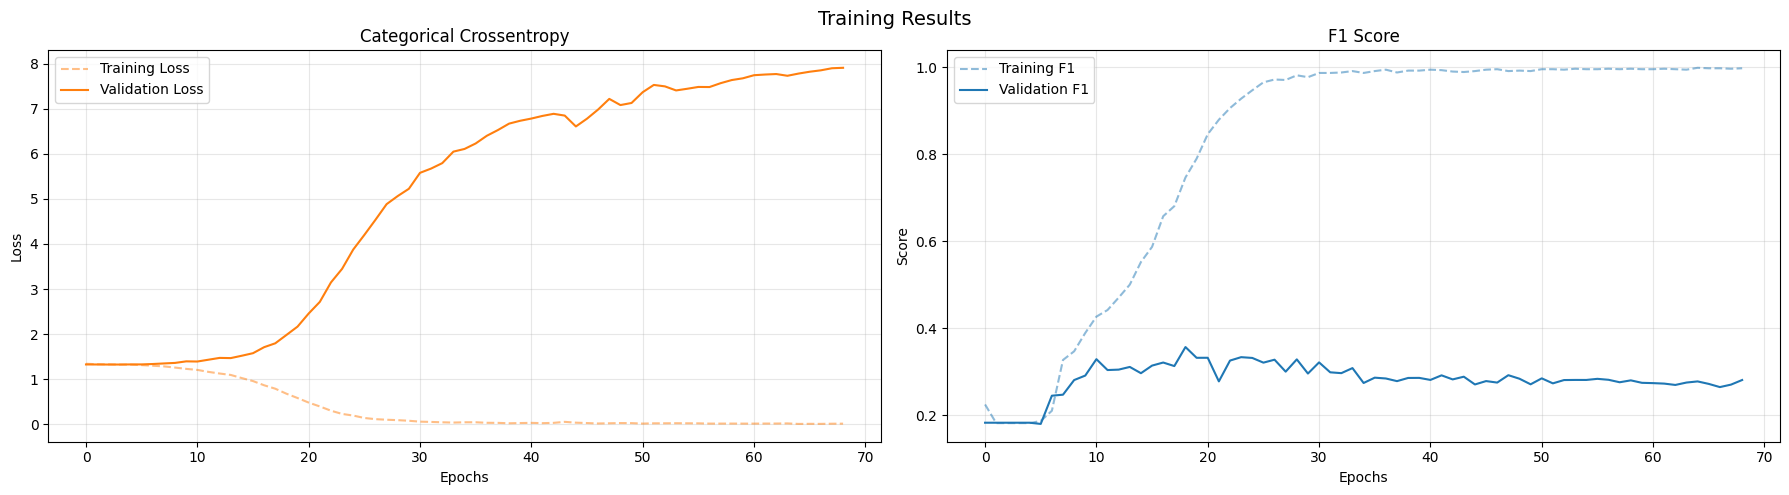

In [35]:
if PLOT_FLAG:
    cplot.plot_training_history(vanilla_history, title=f"Training Results")

## Test Prediction

In [36]:
def get_predictions(model, loader, device):
    print(f"--- Starting Inference on {len(loader.dataset)} Samples ---")
    model.eval()
    all_predictions = []
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            # Handle both (inputs, labels) or just (inputs) loaders
            inputs = batch[0].to(device)
            
            # Forward pass using mixed precision
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
            
            # Get class indices
            preds = logits.argmax(dim=1).cpu().numpy()
            all_predictions.extend(preds)
            
    print("Inference complete.")
    return np.array(all_predictions)

In [37]:

def create_submission_csv(predictions, filenames, encoder, output_csv="submission.csv"):

    if len(predictions) != len(filenames):
        raise ValueError(f"Mismatch: {len(predictions)} predictions vs {len(filenames)} filenames")

    print(f"Decoding {len(predictions)} labels...")
    predicted_labels = encoder.inverse_transform(predictions)
    
    submission_df = pd.DataFrame({
        'sample_index': filenames,
        'label': predicted_labels
    })
    
    submission_df.to_csv(output_csv, index=False)
    print(f"Saved submission to '{output_csv}'")
    print(submission_df.head())
    
    return submission_df

In [38]:

# --- Prepare Test Data ---
X_test_tensor = preprocess_inputs(test_images, test_masks)
test_ds = TensorDataset(X_test_tensor)
test_filenames = get_sorted_filenames(TEST_DATA_PATH)

# --- Create DataLoaders ---
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Test Shape:  {test_ds[0][0].shape} | Samples: {len(test_ds)}")

# --- Check for best model ---
if 'best_model' not in locals() or best_model is None:
    print("Best model not found, using last trained model state.")
    best_model = vanilla_model

# 1. Run Predictions
raw_predictions = get_predictions(best_model, test_loader, device)


# 2. Generate CSV
_ = create_submission_csv(
    predictions=raw_predictions,
    filenames=test_filenames,
    encoder=label_encoder,
    output_csv="submission.csv"
)

Test Shape:  torch.Size([4, 224, 224]) | Samples: 954
--- Starting Inference on 954 Samples ---
Inference complete.
Decoding 954 labels...
Saved submission to 'submission.csv'
   sample_index      label
0  img_0000.png  Luminal B
1  img_0001.png  Luminal A
2  img_0002.png    HER2(+)
3  img_0003.png  Luminal B
4  img_0004.png  Luminal A
